# Notebook: 00 Image Extract
## Purpose: extract image archives, clean folders, preview images, and build masks from annotations.

In [8]:
from src.utils.config import Config
from src.utils.helpers import init_notebook


config = Config.load()

init_notebook(config.train.seed)


=== init_notebook ===
Done


In [9]:
import random
import shutil
import zipfile
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
from PIL import Image

from src.data.annotations import load_json_annotations
from src.data.masks import save_mask
from src.utils.helpers import p, t


root = Path(config.paths.root)
train_zip = config.paths.train_images_zip

train_dir = config.paths.train_images
eval_dir = config.paths.eval_images
mask_dir = config.paths.train_masks


#### Extract images and remove __MACOSX folders

In [10]:
# Mapping of zip files to their extraction targets
for zip_path, extract_to in [(train_zip, train_dir)]:
    if zip_path and Path(zip_path).exists():

        p("Working", str(zip_path))

        extract_to.mkdir(parents = True, exist_ok = True)

        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_to)

            src_rel = Path(zip_path).resolve().relative_to(root)
            dst_rel = Path(extract_to).resolve().relative_to(root)
            p("Extracted", f"{src_rel} -> {dst_rel}")

        for m in extract_to.rglob("__MACOSX"):
            if m.is_dir():
                shutil.rmtree(m)
                rel = m.resolve().relative_to(root)
                p("Removed", str(rel))

    elif zip_path:
        p("Zip path not found", str(zip_path))

Working: C:\github\Tree-Canopy-Detection\src\data\data1\train_images.zip
Extracted: src\data\data1\train_images.zip -> src\data\data1\train_images
Removed: src\data\data1\train_images\__MACOSX


#### Preview images

=== Path C:\github\Tree-Canopy-Detection\src\data\data1\train_images ===


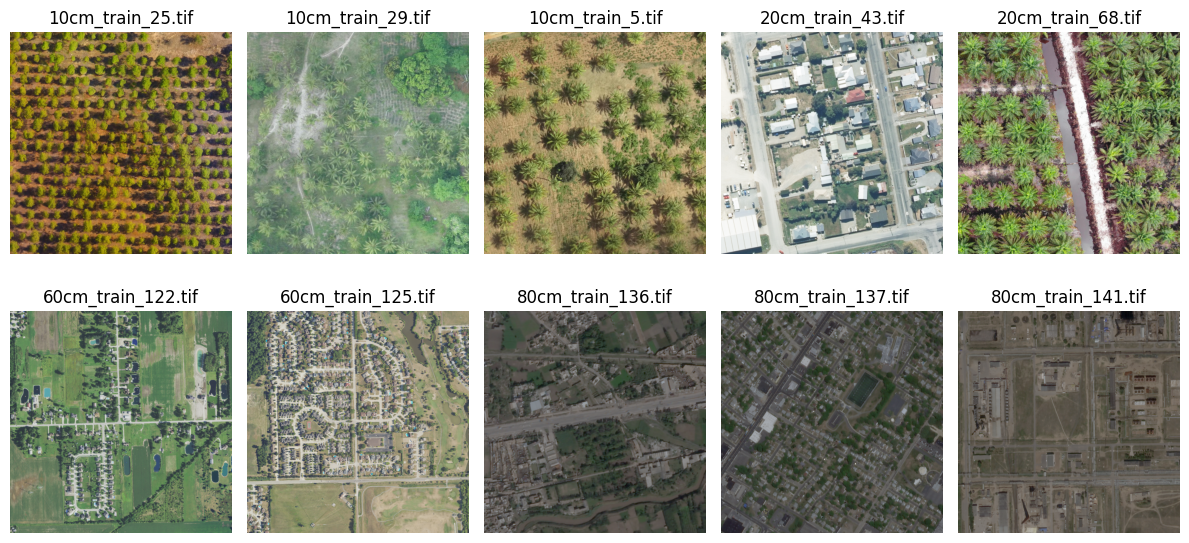

C:\github\Tree-Canopy-Detection\src\data\data1\train_images
C:\github\Tree-Canopy-Detection\src\data\data1\train_images
=== Path C:\github\Tree-Canopy-Detection\src\data\data1\evaluation_images ===


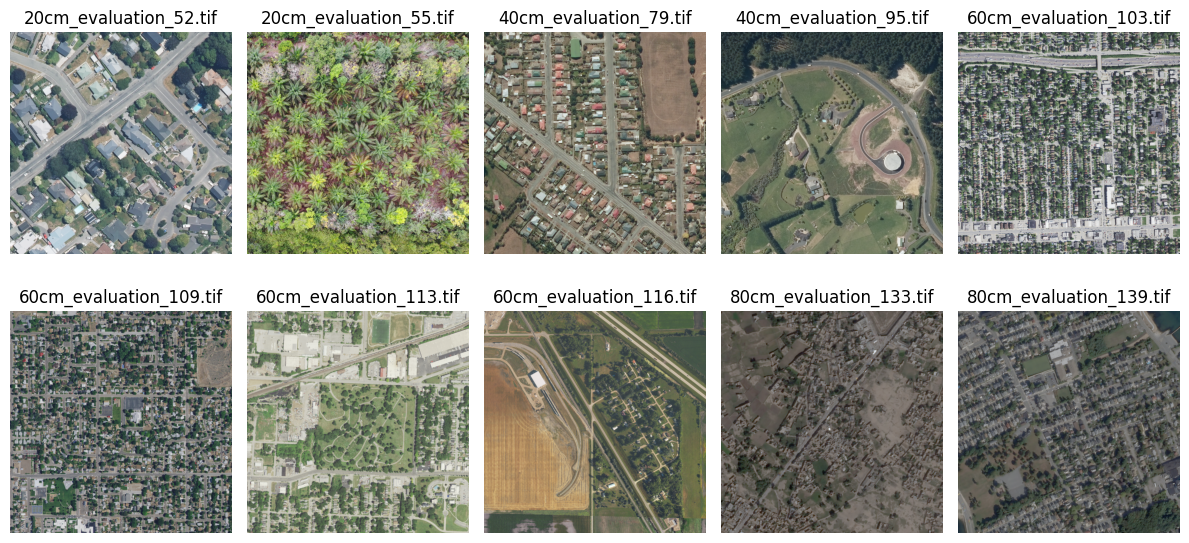

In [26]:
sample_train_set = None
for folder in [train_dir, eval_dir]:
    t(f"Path {folder}")
    files = [f for f in folder.glob("*.*") if f.suffix.lower() in [".tif"]]
    sample = random.sample(files, min(10, len(files)))
    sample = sorted(sample, key = lambda f: f.stem)
    plt.figure(figsize = (12, 6))
    for i, path in enumerate(sample, 1):
        with Image.open(path) as img:
            plt.subplot(2, 5, i)
            plt.imshow(img)
            plt.title(path.name)
            plt.axis("off")
    plt.tight_layout()
    plt.show()

    if folder == train_dir:
        sample_train_set = sample

#### Build masks from annotation json

In [12]:
annotations_path = config.paths.annotations
entries = load_json_annotations(annotations_path)
mask_dir.mkdir(parents = True, exist_ok = True)

for entry in entries:
    image_path = train_dir / entry.image_path.name
    if not image_path.exists():
        continue

    mask = entry.to_mask()
    save_path = mask_dir / entry.image_path.name
    save_mask(mask, save_path)

#### Preview masks with overlays

=== Path C:\github\Tree-Canopy-Detection\src\data\data1\train_masks ===


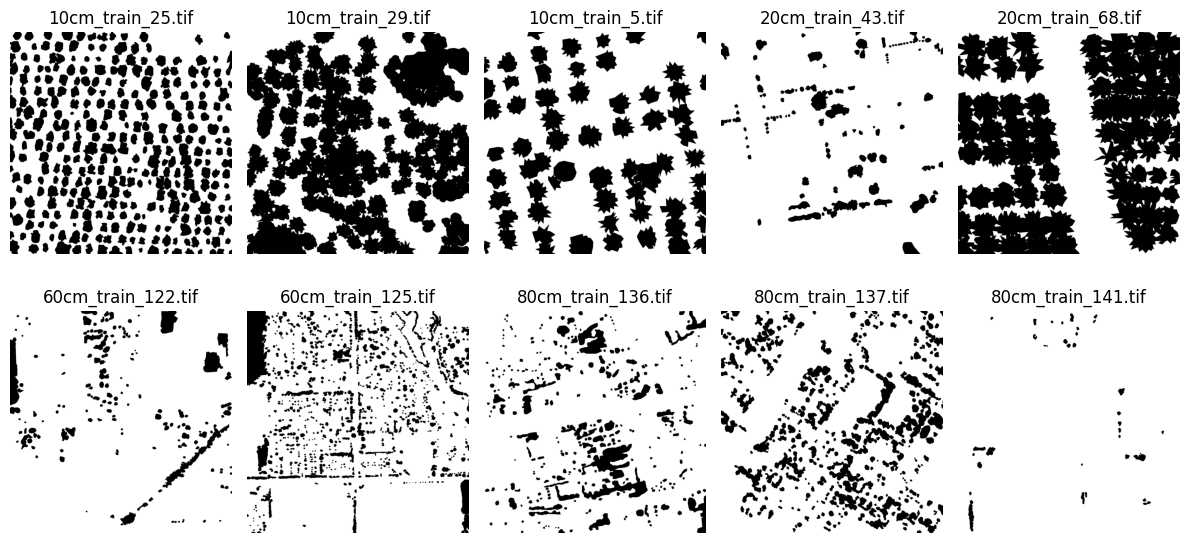

In [27]:
t(f"Path {mask_dir}")

sample_train_filenames = { Path(p).stem for p in sample_train_set }

sample = sorted([f for f in mask_dir.glob("*.*") if f.stem in sample_train_filenames])
sample = sorted(sample, key = lambda f: f.stem)

plt.figure(figsize = (12, 6))
for i, path in enumerate(sample, 1):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    plt.subplot(2, 5, i)
    plt.imshow(mask, cmap = "Grays")
    plt.title(path.name)
    plt.axis("off")
plt.tight_layout()
plt.show()
